# DataBento MBO: Limit Order Book Reconstruction

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Reconstruct the NASDAQ limit order book for one symbol-day from DataBento
MBO messages, compute spread and depth features, and emit the per-snapshot
parquet that the bar-sampling and trade-classification notebooks reuse.

## Learning Objectives

After completing this notebook, you will be able to:
- Process DataBento MBO `A`/`C`/`M`/`F`/`T`/`R` messages with correct
  semantics (`F` updates book state, `T` is trade tape only).
- Build the modular `OrderState -> PriceLevel -> BookSide -> LOB`
  reconstruction engine and handle venue quirks (UNDEF_PRICE, unknown
  order IDs, top-of-book-only feeds).
- Compute and validate microstructure features from snapshots: best bid /
  ask, mid, spread (absolute and bps), depth at multiple levels.

## Book reference

Section §3.3, *From Raw Messages to the Limit Order Book* — Figure 3.2
(Nasdaq-visible spread distribution) is sourced from this notebook.

## Prerequisites

- DataBento XNAS-ITCH MBO parquets at
  `data/equities/market/microstructure/market_by_order/{SYMBOL}/`.

## Key Insight: T vs F Messages

DataBento MBO generates **two messages per execution**:

| Message | Book Update? | Use For |
|---------|--------------|---------|
| **F (Fill)** | YES | Reduces resting order size |
| **T (Trade)** | NO | Trade tape, aggressor labels for bars |

We process F for book state; we use T for building bars (see
`17_databento_bar_sampling`).

---

## Setup

In [1]:
"""DataBento MBO: Limit Order Book Reconstruction — modular LOB engine from MBO messages."""

from __future__ import annotations

import warnings
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

# Import loader for MBO data
from data import load_mbo_data

# ML4T imports - path resolution
from utils.paths import get_output_dir

# Polars display configuration

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

In [3]:
sns.set_style("whitegrid")

In [4]:
# =============================================================================
# Configuration
# =============================================================================

OUTPUT_DIR = get_output_dir(3, "databento")

SYMBOL = "NVDA"
# Get file paths from the canonical loader (handles legacy/new path resolution)
data_files = load_mbo_data(symbols=[SYMBOL], list_files=True)
SYMBOL_DATA_DIR = data_files[0].parent if data_files else None

# Price scaling: DataBento raw format uses nanodollars (1e9 scale), but our
# parquet files may be pre-converted to dollars. We auto-detect below.
# If prices are > 1e6, they're likely nanodollars; otherwise dollars.
PRICE_SCALE_NANODOLLARS = 1e9
PRICE_SCALE_DOLLARS = 1.0

# DataBento record flags (bitmask)
# See: https://databento.com/docs/standards-and-conventions/common-fields-enums-types
F_LAST = 128  # Last message in event
F_TOB = 32  # Top-of-book only (IEXG, NYSE National)
F_SNAPSHOT = 8  # Snapshot message
F_MAYBE_BAD = 2  # Possibly erroneous

# UNDEF_PRICE constant (maximum int64 - 1)
UNDEF_PRICE = 9223372036854775807

## 1. Load MBO Data

We load DataBento MBO data and filter to Regular Trading Hours (RTH).
Note: The UTC hour filter is an approximation; production systems should
use a proper market calendar with DST handling.

### Select Columns and Cast Timestamps
Keep only the columns needed for LOB reconstruction and ensure nanosecond timestamp types.

In [5]:
MBO_COLUMNS = [
    "ts_event",
    "ts_recv",
    "action",
    "side",
    "price",
    "size",
    "order_id",
    "flags",
    "publisher_id",
]


def _select_and_cast_columns(df: pl.DataFrame) -> pl.DataFrame:
    """Select MBO columns and cast timestamps to nanosecond datetime."""
    cols = [c for c in MBO_COLUMNS if c in df.columns]
    df = df.select(cols)
    if "ts_event" in df.columns:
        df = df.with_columns(pl.col("ts_event").cast(pl.Datetime("ns")))
    if "ts_recv" in df.columns:
        df = df.with_columns(pl.col("ts_recv").cast(pl.Datetime("ns")))
    return df

### Load, Filter, and Sort
Read the parquet file, select columns, sort chronologically, and filter to RTH.

In [6]:
def load_mbo_data(file_path: Path, max_rows: int | None = None) -> pl.DataFrame:
    """Load and preprocess DataBento MBO data.

    Args:
        file_path: Path to parquet file
        max_rows: Maximum rows to return (for testing)

    Returns:
        DataFrame with MBO messages, filtered to RTH and sorted by timestamp
    """
    df = _select_and_cast_columns(pl.read_parquet(file_path))

    # Sort by event timestamp, then order_id for deterministic ordering
    sort_cols = ["ts_event"] if "ts_event" in df.columns else ["ts_recv"]
    if "order_id" in df.columns:
        sort_cols.append("order_id")
    df = df.sort(sort_cols)

    # Filter to RTH (13:30-21:00 UTC = 9:30-16:00 ET, ignoring DST).
    # Production should use a proper market calendar to handle DST and holidays.
    ts_col = "ts_event" if "ts_event" in df.columns else "ts_recv"
    df = df.filter(
        (
            (pl.col(ts_col).dt.hour() > 13)
            | ((pl.col(ts_col).dt.hour() == 13) & (pl.col(ts_col).dt.minute() >= 30))
        )
        & (pl.col(ts_col).dt.hour() < 21)
    )

    if max_rows is not None:
        df = df.head(max_rows)

    return df

In [7]:
# Load data
mbo = None
preprocessed_path = OUTPUT_DIR / f"{SYMBOL}_mbo_rth.parquet"

if preprocessed_path.exists():
    print(f"Loading from {preprocessed_path}...")
    mbo = pl.read_parquet(preprocessed_path)
    print(f"Messages: {len(mbo):,}")
else:
    data_files = sorted(SYMBOL_DATA_DIR.glob("*.parquet")) if SYMBOL_DATA_DIR.exists() else []
    if data_files:
        print(f"Loading from {data_files[0].name}...")
        mbo = load_mbo_data(data_files[0])
        print(f"Messages: {len(mbo):,}")
    else:
        print("No DataBento data found. This notebook requires DataBento MBO data.")
        print(f"Expected location: {SYMBOL_DATA_DIR}")

Loading from xnas-itch-20241104.mbo.dbn.parquet...


Messages: 8,788,216


In [8]:
# Brief data exploration
if mbo is not None and len(mbo) > 0:
    # Message type distribution
    action_counts = mbo.group_by("action").len().sort("len", descending=True)
    total = len(mbo)

    print("\n=== Message Type Distribution ===")
    for row in action_counts.iter_rows():
        action, count = row
        pct = count / total * 100
        label = {
            "A": "Add",
            "C": "Cancel",
            "M": "Modify",
            "F": "Fill",
            "T": "Trade",
            "R": "Reset",
        }.get(action, action)
        print(f"  {action} ({label:7s}): {count:>10,} ({pct:5.1f}%)")

    # Side attribution for trades (key for bar construction)
    trades = mbo.filter(pl.col("action") == "T")
    if len(trades) > 0:
        side_counts = trades.group_by("side").len().sort("side")
        total_trades = len(trades)

        print("\n=== Trade Side Attribution ===")
        for row in side_counts.iter_rows():
            side, count = row
            pct = count / total_trades * 100
            label = {"B": "Buy", "A": "Sell", "N": "Unknown"}.get(side, side)
            print(f"  {side}: {count:>10,} ({pct:5.1f}%) - {label}")

        usable = trades.filter(pl.col("side") != "N").height
        print(f"\n  Usable for imbalance bars: {usable:,} ({usable / total_trades * 100:.1f}%)")


=== Message Type Distribution ===
  A (Add    ):  4,306,480 ( 49.0%)
  C (Cancel ):  4,114,356 ( 46.8%)
  T (Trade  ):    200,166 (  2.3%)
  F (Fill   ):    167,214 (  1.9%)

=== Trade Side Attribution ===
  A:     82,311 ( 41.1%) - Sell
  B:     84,896 ( 42.4%) - Buy
  N:     32,959 ( 16.5%) - Unknown

  Usable for imbalance bars: 167,207 (83.5%)


## 2. LOB Reconstruction Engine

We build the LOB reconstruction as modular components. This design is more
maintainable and testable than a monolithic function.

### 2.1 Order State Tracking

Each order in the book is tracked with its current state.

In [9]:
@dataclass(slots=True)
class OrderState:
    """State of a single order in the book.

    Attributes:
        side: 'B' for bid, 'A' for ask
        price: Price (raw nanodollars or pre-scaled dollars)
        size: Current size (decremented by fills/cancels)
        is_tob: True if this is a top-of-book synthetic order
    """

    side: str
    price: int | float
    size: int
    is_tob: bool = False

### 2.2 Price Level Aggregation

A price level aggregates all orders at a single price point.

In [10]:
@dataclass(slots=True)
class PriceLevel:
    """Aggregated depth at a single price level.

    Attributes:
        price: Price (raw or scaled)
        size: Total size across all orders
        order_count: Number of distinct orders (excluding TOB synthetic orders)
    """

    price: int | float
    size: int = 0
    order_count: int = 0

### 2.3 Book Side Management

Each side (bid/ask) of the book is managed separately with a sorted structure.

In [11]:
@dataclass
class BookSide:
    """One side of the limit order book (bids or asks).

    Uses a Counter for O(1) add/remove and sorts only when querying levels.
    This is more efficient than maintaining a sorted structure for high-frequency
    updates where we only need the top levels occasionally.

    Attributes:
        levels: Price -> total size mapping
        order_ids: Set of order IDs on this side (for count)
        is_bid: True for bid side (descending sort), False for ask (ascending)
    """

    levels: Counter = field(default_factory=Counter)
    order_ids: set = field(default_factory=set)
    is_bid: bool = True

    def add_size(self, price: int | float, size: int, order_id: int | None = None) -> None:
        """Add size at a price level."""
        self.levels[price] += size
        if order_id is not None:
            self.order_ids.add(order_id)

    def remove_size(self, price: int | float, size: int, order_id: int | None = None) -> None:
        """Remove size from a price level (clamped to available)."""
        available = self.levels.get(price, 0)
        decrement = min(size, available)
        self.levels[price] -= decrement
        if self.levels[price] <= 0:
            del self.levels[price]
        if order_id is not None:
            self.order_ids.discard(order_id)

    def clear(self) -> None:
        """Clear all levels (for TOB replacement or reset)."""
        self.levels.clear()
        self.order_ids.clear()

    def get_top_levels(self, n: int) -> list[PriceLevel]:
        """Get top N price levels, sorted by price priority.

        For bids: highest prices first (descending)
        For asks: lowest prices first (ascending)

        Note: order_count is not tracked per-level and returns 0.
        For true order counts, production systems should track orders per level.
        """
        if not self.levels:
            return []

        # Sort prices by priority
        prices = sorted(self.levels.keys(), reverse=self.is_bid)[:n]

        # order_count=0 indicates we don't track per-level order counts
        # (would require mapping orders to price levels, not implemented)
        return [PriceLevel(price=p, size=self.levels[p], order_count=0) for p in prices]

    def get_best_price(self) -> int | float | None:
        """Get the best (top) price, or None if empty."""
        if not self.levels:
            return None
        if self.is_bid:
            return max(self.levels.keys())
        return min(self.levels.keys())

    def get_total_depth(self, n_levels: int | None = None) -> int:
        """Get total depth across top N levels (or all if None)."""
        if n_levels is None:
            return sum(self.levels.values())
        top = self.get_top_levels(n_levels)
        return sum(level.size for level in top)

### 2.4 Limit Order Book

The complete LOB combines both sides and computes features.

In [12]:
@dataclass
class LimitOrderBook:
    """Complete limit order book with bid and ask sides.

    Handles:
    - Order tracking via registry
    - Add, Modify, Cancel, Fill, Trade, Reset actions
    - Top-of-book (TOB) flag for venues like IEXG
    - UNDEF_PRICE for clearing sides
    - Feature computation (spread, depth, imbalance)

    Attributes:
        bids: Bid side of the book
        asks: Ask side of the book
        orders: Registry mapping order_id -> OrderState
        price_scale: Divisor to convert raw prices to dollars
    """

    bids: BookSide = field(default_factory=lambda: BookSide(is_bid=True))
    asks: BookSide = field(default_factory=lambda: BookSide(is_bid=False))
    orders: dict[int, OrderState] = field(default_factory=dict)
    price_scale: float = 1.0  # Set by reconstructor after detecting format

    # Diagnostic counters
    unknown_order_count: int = 0
    negative_size_count: int = 0

    def _get_side(self, side: str) -> BookSide:
        """Get the appropriate book side."""
        return self.bids if side == "B" else self.asks

The `apply` method processes each MBO action (Add, Modify, Cancel, Fill,
Trade, Reset) to update book state, handling both full-depth and
top-of-book venues.

In [13]:
def _apply_tob_replace(self, side, price, size, order_id, book_side):
    """Replace entire side for top-of-book venues (IEXG, NYSE National)."""
    stale_ids = [oid for oid, order in self.orders.items() if order.side == side and order.is_tob]
    for oid in stale_ids:
        del self.orders[oid]
    book_side.clear()
    book_side.add_size(price, size, order_id=None)
    self.orders[order_id] = OrderState(side, price, size, is_tob=True)


LimitOrderBook._apply_tob_replace = _apply_tob_replace

### Cancel/Fill Handler
Remove size from the book on Cancel or Fill actions.

In [14]:
def _apply_cancel_fill(self, size, order_id):
    """Handle Cancel/Fill — use EXISTING order's side, not message side."""
    existing = self.orders.get(order_id)
    if existing is None:
        self.unknown_order_count += 1
        return

    existing_side = self._get_side(existing.side)
    actual_decrement = min(size, existing.size)
    if actual_decrement < size:
        self.negative_size_count += 1

    existing_side.remove_size(existing.price, actual_decrement, None)
    existing.size -= actual_decrement

    if existing.size <= 0:
        del self.orders[order_id]
        existing_side.order_ids.discard(order_id)


LimitOrderBook._apply_cancel_fill = _apply_cancel_fill

### Apply Action Dispatcher
Route each MBO action (Add, Cancel, Fill, Modify, Trade, Clear) to the appropriate handler.

In [15]:
def _apply(
    self,
    action: str,
    side: str,
    price: int | float,
    size: int,
    order_id: int,
    flags: int = 0,
) -> None:
    """Apply an MBO message to update book state.

    Args:
        action: Message action (A, M, C, F, T, R, N)
        side: Order side (A=ask, B=bid, N=neutral)
        price: Price (raw nanodollars or pre-scaled dollars)
        size: Size (shares)
        order_id: Unique order identifier
        flags: DataBento flags bitmask
    """
    if action in ("T", "N"):
        return

    if action == "R":
        self.bids.clear()
        self.asks.clear()
        self.orders.clear()
        return

    if side == "N":
        return

    book_side = self._get_side(side)

    # UNDEF_PRICE with TOB flag: clear entire side
    if price == UNDEF_PRICE and (flags & F_TOB):
        book_side.clear()
        return

    if action == "A":
        if flags & F_TOB:
            self._apply_tob_replace(side, price, size, order_id, book_side)
        else:
            self.orders[order_id] = OrderState(side, price, size)
            book_side.add_size(price, size, order_id)

    elif action == "M":
        if flags & F_TOB:
            self._apply_tob_replace(side, price, size, order_id, book_side)
        else:
            existing = self.orders.get(order_id)
            if existing is None:
                self.unknown_order_count += 1
                self.orders[order_id] = OrderState(side, price, size)
                book_side.add_size(price, size, order_id)
            else:
                old_side = self._get_side(existing.side)
                old_side.remove_size(existing.price, existing.size, order_id)
                self.orders[order_id] = OrderState(side, price, size)
                book_side.add_size(price, size, order_id)

    elif action in ("C", "F"):
        self._apply_cancel_fill(size, order_id)


LimitOrderBook.apply = _apply

### 2.4b Feature Computation Methods

BBO, spread, and depth features are added to `LimitOrderBook` as methods.

In [16]:
def _get_bbo(self) -> tuple[float | None, float | None]:
    """Get best bid and ask prices in dollars."""
    best_bid = self.bids.get_best_price()
    best_ask = self.asks.get_best_price()
    # Use explicit None check (price=0 is technically valid, though rare)
    return (
        best_bid / self.price_scale if best_bid is not None else None,
        best_ask / self.price_scale if best_ask is not None else None,
    )


LimitOrderBook.get_bbo = _get_bbo

### Spread Computation
Compute bid-ask spread in basis points from the current BBO.

In [17]:
def _get_spread_bps(self) -> float | None:
    """Get bid-ask spread in basis points."""
    best_bid, best_ask = self.get_bbo()
    if best_bid is None or best_ask is None:
        return None
    mid = (best_bid + best_ask) / 2
    if mid <= 0:
        return None
    return ((best_ask - best_bid) / mid) * 10000


LimitOrderBook.get_spread_bps = _get_spread_bps

### Feature Extraction
Compute microstructure features (spread, depth, imbalance) from current book state.

In [18]:
def _get_features(self, n_levels: int = 5) -> dict[str, Any]:
    """Compute microstructure features from current book state.

    Args:
        n_levels: Number of price levels to include in depth

    Returns:
        Dictionary with spread, depth, and imbalance features
    """
    best_bid, best_ask = self.get_bbo()

    if best_bid is None or best_ask is None:
        return {}

    mid_price = (best_bid + best_ask) / 2
    spread = best_ask - best_bid
    spread_bps = (spread / mid_price) * 10000 if mid_price > 0 else 0

    bid_depth = self.bids.get_total_depth(n_levels)
    ask_depth = self.asks.get_total_depth(n_levels)
    total_depth = bid_depth + ask_depth
    depth_imbalance = (bid_depth - ask_depth) / total_depth if total_depth > 0 else 0

    # Per-level sizes
    bid_levels = self.bids.get_top_levels(n_levels)
    ask_levels = self.asks.get_top_levels(n_levels)

    features = {
        "best_bid": best_bid,
        "best_ask": best_ask,
        "mid_price": mid_price,
        "spread": spread,
        "spread_bps": spread_bps,
        "bid_depth": bid_depth,
        "ask_depth": ask_depth,
        "total_depth": total_depth,
        "depth_imbalance": depth_imbalance,
    }

    # Add per-level sizes AND prices (pad with 0/NaN if fewer levels available).
    # Per-level prices are needed downstream (e.g. Figure 3.2 generator) to
    # render the bid/ask depth profile as price-by-volume bars.
    for i in range(n_levels):
        features[f"bid_size_{i + 1}"] = bid_levels[i].size if i < len(bid_levels) else 0
        features[f"ask_size_{i + 1}"] = ask_levels[i].size if i < len(ask_levels) else 0
        features[f"bid_price_{i + 1}"] = (
            bid_levels[i].price if i < len(bid_levels) else float("nan")
        )
        features[f"ask_price_{i + 1}"] = (
            ask_levels[i].price if i < len(ask_levels) else float("nan")
        )

    return features


LimitOrderBook.get_features = _get_features

### 2.5 LOB Reconstructor

The reconstructor processes a stream of MBO messages and takes periodic snapshots.
It uses **numpy arrays** for iteration instead of `to_dicts()` for better performance.

In [19]:
class LOBReconstructor:
    """Processes MBO messages to reconstruct LOB and compute features.

    Performance optimizations:
    - Extracts columns as numpy arrays (avoids to_dicts() overhead)
    - Uses integer nanoseconds for snapshot timing (avoids datetime conversion)
    - Processes messages in a tight loop with minimal Python overhead

    Usage:
        reconstructor = LOBReconstructor(snapshot_freq_ms=5000, n_levels=5)
        snapshots_df = reconstructor.process(mbo_dataframe)
    """

    def __init__(
        self,
        snapshot_freq_ms: int = 5000,
        n_levels: int = 5,
        price_scale: float | None = None,
    ):
        """Initialize the reconstructor.

        Args:
            snapshot_freq_ms: Milliseconds between snapshots (default 5000 = 5 sec)
            n_levels: Number of price levels for depth features
            price_scale: Divisor for converting raw prices to dollars (auto-detected if None)
        """
        self.snapshot_freq_ms = snapshot_freq_ms
        self.n_levels = n_levels
        self.price_scale = price_scale  # Will auto-detect if None

### Extract Numpy Arrays
Convert selected Polars columns to numpy arrays for fast iteration (5-10x faster
than `to_dicts()`).

In [20]:
def _mbo_to_numpy(
    messages: pl.DataFrame, ts_col: str
) -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """Extract MBO columns as numpy arrays for the snapshot loop."""
    has_flags = "flags" in messages.columns
    df = messages.select(
        [
            pl.col(ts_col).alias("ts"),
            pl.col("action"),
            pl.col("side"),
            pl.col("price"),
            pl.col("size"),
            pl.col("order_id"),
        ]
        + ([pl.col("flags")] if has_flags else [])
    ).with_columns(pl.col("ts").dt.epoch("ns").alias("ts_ns"))

    return (
        df["ts"].to_numpy(),
        df["ts_ns"].to_numpy(),
        df["action"].to_numpy(),
        df["side"].to_numpy(),
        df["price"].to_numpy(),
        df["size"].to_numpy(),
        df["order_id"].to_numpy(),
        df["flags"].to_numpy() if has_flags else np.zeros(len(df), dtype=np.uint8),
    )

The `process` method validates columns, auto-detects price scaling, extracts
numpy arrays for fast iteration, and runs the snapshot loop.

In [21]:
def _prepare_mbo_arrays(
    self, messages: pl.DataFrame
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    float,
]:
    """Validate columns, detect price scale, and extract numpy arrays."""
    # Determine timestamp column
    ts_col = "ts_event" if "ts_event" in messages.columns else "ts_recv"

    # Validate required columns
    required = [ts_col, "action", "side", "price", "size", "order_id"]
    missing = [c for c in required if c not in messages.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Auto-detect price scale
    if self.price_scale is None:
        median_price = messages["price"].median()
        if median_price > 1e6:
            price_scale = PRICE_SCALE_NANODOLLARS
            print(f"  Auto-detected price format: nanodollars (scale={price_scale:.0e})")
        else:
            price_scale = PRICE_SCALE_DOLLARS
            print("  Auto-detected price format: dollars (no scaling)")
    else:
        price_scale = self.price_scale

    arrays = _mbo_to_numpy(messages, ts_col)
    return arrays + (price_scale,)


LOBReconstructor._prepare_mbo_arrays = _prepare_mbo_arrays

### Process MBO Messages
Iterate through messages, apply each to the LOB, and capture periodic snapshots.

In [22]:
def _process(self, messages: pl.DataFrame) -> pl.DataFrame:
    """Process MBO messages and return LOB snapshots.

    Args:
        messages: DataFrame with MBO messages. Required columns:
            - ts_event or ts_recv (timestamp)
            - action, side, price, size, order_id
            - flags (optional, for TOB handling)

    Returns:
        DataFrame with one row per snapshot, containing features
    """
    (
        ts_arr,
        ts_ns_arr,
        action_arr,
        side_arr,
        price_arr,
        size_arr,
        order_id_arr,
        flags_arr,
        price_scale,
    ) = self._prepare_mbo_arrays(messages)

    book = LimitOrderBook(price_scale=price_scale)
    snapshots: list[dict[str, Any]] = []
    snapshot_delta_ns = int(self.snapshot_freq_ms) * 1_000_000
    last_snapshot_ns: int | None = None

    n_messages = len(ts_ns_arr)
    for i in range(n_messages):
        action = str(action_arr[i])
        side = str(side_arr[i])
        price = float(price_arr[i])
        size = int(size_arr[i])
        order_id = int(order_id_arr[i])
        flags = int(flags_arr[i])

        book.apply(action, side, price, size, order_id, flags)

        now_ns = int(ts_ns_arr[i])
        if last_snapshot_ns is None or now_ns >= last_snapshot_ns + snapshot_delta_ns:
            features = book.get_features(self.n_levels)
            if features:
                features["timestamp"] = ts_arr[i]
                snapshots.append(features)
            last_snapshot_ns = now_ns

    if book.unknown_order_count > 0:
        print(f"  Warning: {book.unknown_order_count:,} unknown order IDs encountered")
    if book.negative_size_count > 0:
        print(f"  Warning: {book.negative_size_count:,} size clamps (data gaps)")

    return pl.DataFrame(snapshots)


LOBReconstructor.process = _process

## 3. Run LOB Reconstruction

We reconstruct the LOB from a sample of MBO messages and analyze the results.

In [23]:
mbo_sample = None
lob = None

if mbo is not None and len(mbo) > 0:
    # Use first 10 minutes for demo (full reconstruction is computationally intensive)
    ts_col = "ts_event" if "ts_event" in mbo.columns else "ts_recv"
    first_ts = mbo.select(pl.col(ts_col).first()).item()
    end_time = first_ts + pl.duration(minutes=10)
    mbo_sample = mbo.filter(pl.col(ts_col) <= end_time)

    print("Sample period: 10 minutes")
    print(f"Messages: {len(mbo_sample):,}")

    # Show action distribution
    print("\nAction distribution:")
    print(mbo_sample.group_by("action").len().sort("action"))

    # Reconstruct LOB
    print("\nReconstructing LOB...")
    reconstructor = LOBReconstructor(snapshot_freq_ms=5000, n_levels=5)
    lob = reconstructor.process(mbo_sample)
    print(f"Snapshots: {len(lob):,}")

    print("\nSample LOB features:")
    print(lob.head())

Sample period: 10 minutes
Messages: 6,433

Action distribution:
shape: (4, 2)
┌────────┬──────┐
│ action ┆ len  │
│ ---    ┆ ---  │
│ str    ┆ u32  │
╞════════╪══════╡
│ A      ┆ 2617 │
│ C      ┆ 2729 │
│ F      ┆ 454  │
│ T      ┆ 633  │
└────────┴──────┘

Reconstructing LOB...
  Auto-detected price format: dollars (no scaling)


Snapshots: 109

Sample LOB features:
shape: (5, 30)
┌──────────┬──────────┬───────────┬────────┬───┬────────────┬─────────────┬────────────┬───────────┐
│ best_bid ┆ best_ask ┆ mid_price ┆ spread ┆ … ┆ ask_size_5 ┆ bid_price_5 ┆ ask_price_ ┆ timestamp │
│ ---      ┆ ---      ┆ ---       ┆ ---    ┆   ┆ ---        ┆ ---         ┆ 5          ┆ ---       │
│ f64      ┆ f64      ┆ f64       ┆ f64    ┆   ┆ i64        ┆ f64         ┆ ---        ┆ f64       │
│          ┆          ┆           ┆        ┆   ┆            ┆             ┆ f64        ┆           │
╞══════════╪══════════╪═══════════╪════════╪═══╪════════════╪═════════════╪════════════╪═══════════╡
│ 137.94   ┆ 137.97   ┆ 137.955   ┆ 0.03   ┆ … ┆ 100        ┆ NaN         ┆ 140.88     ┆ 1.7307e18 │
│ 137.89   ┆ 137.97   ┆ 137.93    ┆ 0.08   ┆ … ┆ 128        ┆ NaN         ┆ 140.13     ┆ 1.7307e18 │
│ 137.89   ┆ 138.0    ┆ 137.945   ┆ 0.11   ┆ … ┆ 0          ┆ NaN         ┆ NaN        ┆ 1.7307e18 │
│ 135.63   ┆ 137.94   ┆ 136.785   ┆ 2.3

## 4. Spread Analysis

The bid-ask spread is the most fundamental measure of transaction costs.
We analyze its distribution and dynamics.

=== Spread Statistics ===

Mean spread: $0.0520
Median spread: $0.0300
Mean spread (bps): 3.78
Std spread (bps): 16.00


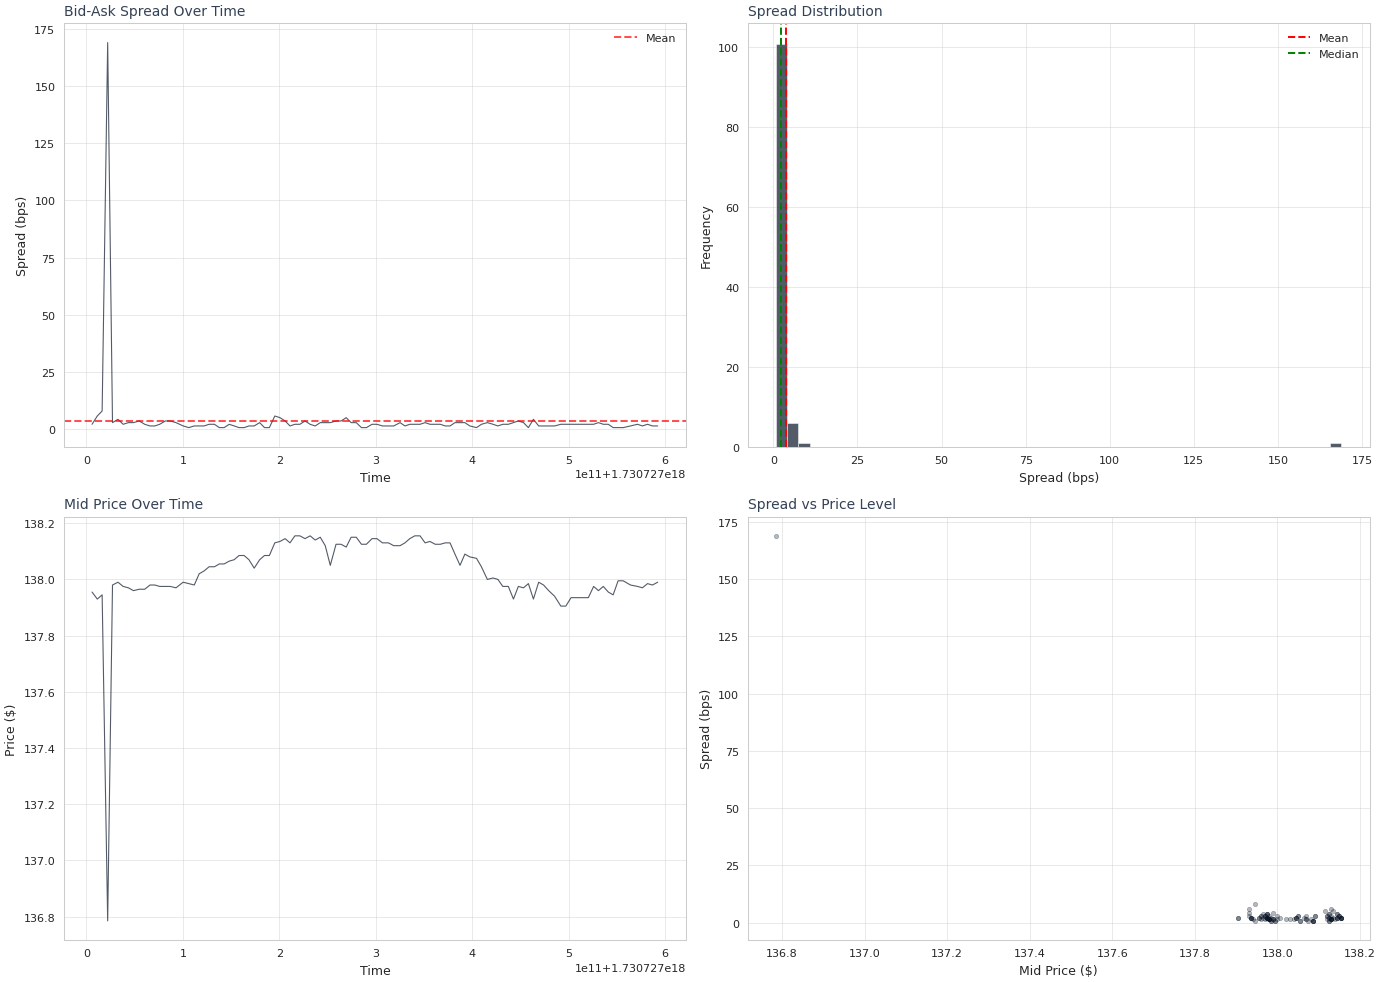

In [24]:
if lob is not None and len(lob) > 0:
    print("=== Spread Statistics ===\n")
    print(f"Mean spread: ${lob['spread'].mean():.4f}")
    print(f"Median spread: ${lob['spread'].median():.4f}")
    print(f"Mean spread (bps): {lob['spread_bps'].mean():.2f}")
    print(f"Std spread (bps): {lob['spread_bps'].std():.2f}")

    # Convert to pandas for matplotlib (at boundary only)
    lob_pd = lob.to_pandas()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Spread over time
    ax = axes[0, 0]
    ax.plot(lob_pd["timestamp"], lob_pd["spread_bps"], alpha=0.7, linewidth=0.8)
    ax.axhline(lob_pd["spread_bps"].mean(), color="red", linestyle="--", label="Mean", alpha=0.7)
    ax.set_title("Bid-Ask Spread Over Time")
    ax.set_xlabel("Time")
    ax.set_ylabel("Spread (bps)")
    ax.legend()

    # Spread distribution
    ax = axes[0, 1]
    ax.hist(lob_pd["spread_bps"], bins=50, edgecolor="white", alpha=0.7)
    ax.axvline(lob_pd["spread_bps"].mean(), color="red", linestyle="--", label="Mean")
    ax.axvline(lob_pd["spread_bps"].median(), color="green", linestyle="--", label="Median")
    ax.set_title("Spread Distribution")
    ax.set_xlabel("Spread (bps)")
    ax.set_ylabel("Frequency")
    ax.legend()

    # Mid price
    ax = axes[1, 0]
    ax.plot(lob_pd["timestamp"], lob_pd["mid_price"], alpha=0.7, linewidth=0.8)
    ax.set_title("Mid Price Over Time")
    ax.set_xlabel("Time")
    ax.set_ylabel("Price ($)")

    # Spread vs price
    ax = axes[1, 1]
    ax.scatter(lob_pd["mid_price"], lob_pd["spread_bps"], alpha=0.3, s=10)
    ax.set_title("Spread vs Price Level")
    ax.set_xlabel("Mid Price ($)")
    ax.set_ylabel("Spread (bps)")

    plt.tight_layout()
    plt.show()

## 5. Depth Analysis

Market depth measures liquidity available at various price levels.
Depth imbalance (bid depth vs ask depth) is a predictor of short-term price movements.

In [25]:
# Depth statistics and data preparation
if lob is not None and len(lob) > 0:
    print("=== Depth Statistics ===\n")
    print(f"Mean bid depth: {lob['bid_depth'].mean():,.0f}")
    print(f"Mean ask depth: {lob['ask_depth'].mean():,.0f}")
    print(f"Mean depth imbalance: {lob['depth_imbalance'].mean():.4f}")
    print(f"Std depth imbalance: {lob['depth_imbalance'].std():.4f}")

    # Add price change for predictability analysis
    lob_pd = lob.to_pandas()
    lob_pd["price_change"] = lob_pd["mid_price"].pct_change() * 10000  # bps

=== Depth Statistics ===

Mean bid depth: 1,413
Mean ask depth: 2,377
Mean depth imbalance: -0.1874
Std depth imbalance: 0.3497


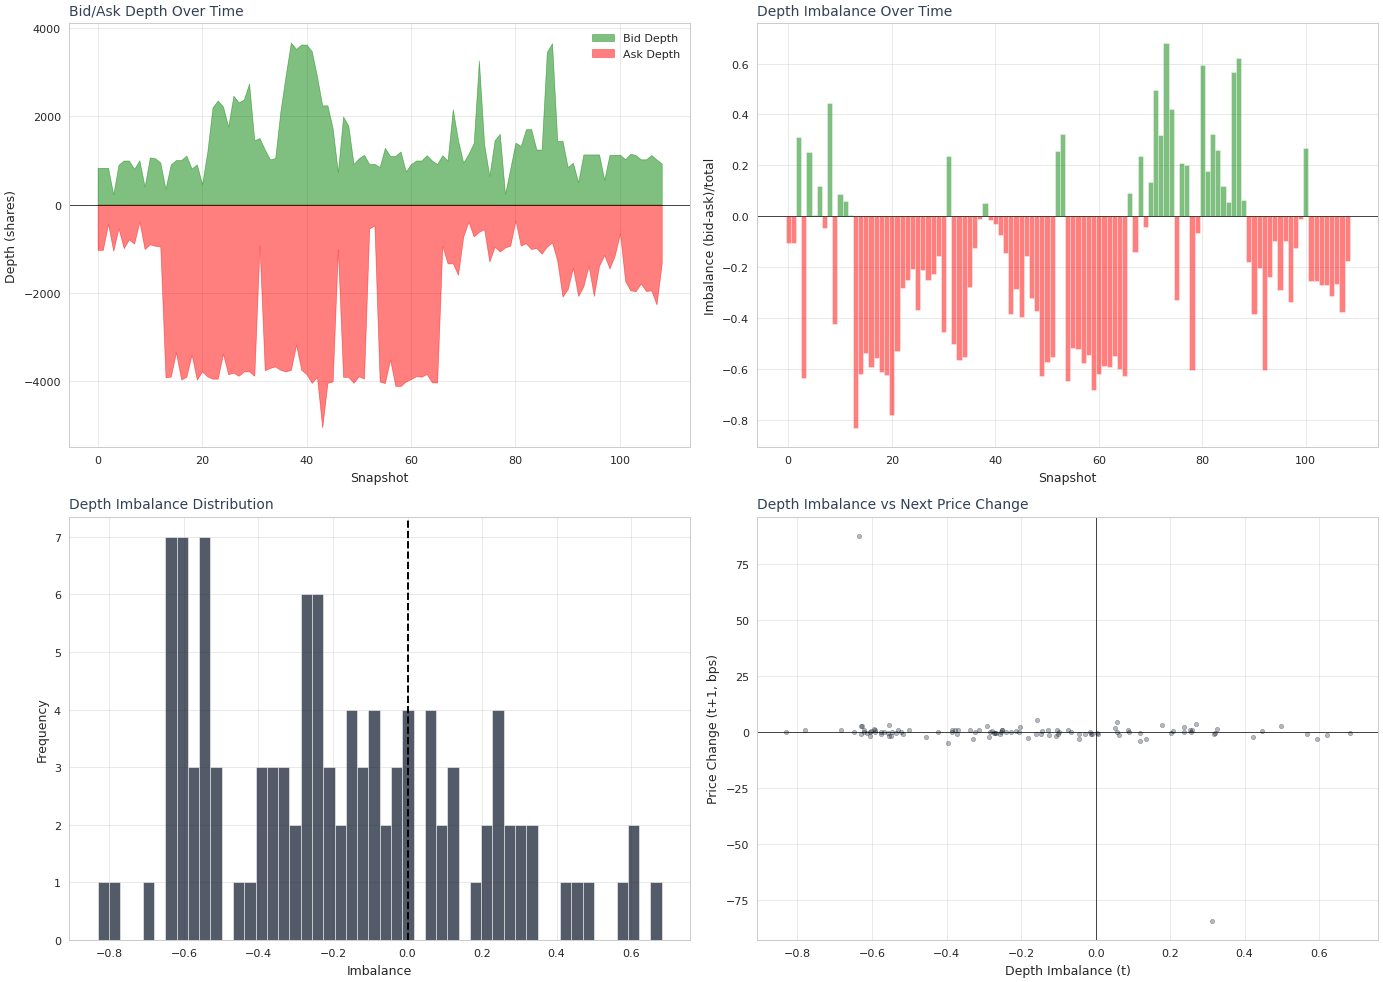

In [26]:
# Depth visualization (4-panel: depth, imbalance time series, distribution, predictability)
if lob is not None and len(lob) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.fill_between(
        range(len(lob_pd)), lob_pd["bid_depth"], alpha=0.5, label="Bid Depth", color="green"
    )
    ax.fill_between(
        range(len(lob_pd)), -lob_pd["ask_depth"], alpha=0.5, label="Ask Depth", color="red"
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Bid/Ask Depth Over Time")
    ax.set_xlabel("Snapshot")
    ax.set_ylabel("Depth (shares)")
    ax.legend()

    ax = axes[0, 1]
    colors = ["green" if x > 0 else "red" for x in lob_pd["depth_imbalance"]]
    ax.bar(range(len(lob_pd)), lob_pd["depth_imbalance"], color=colors, alpha=0.5, width=1.0)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Depth Imbalance Over Time")
    ax.set_xlabel("Snapshot")
    ax.set_ylabel("Imbalance (bid-ask)/total")

    ax = axes[1, 0]
    ax.hist(lob_pd["depth_imbalance"], bins=50, edgecolor="white", alpha=0.7)
    ax.axvline(0, color="black", linestyle="--")
    ax.set_title("Depth Imbalance Distribution")
    ax.set_xlabel("Imbalance")
    ax.set_ylabel("Frequency")

    ax = axes[1, 1]
    ax.scatter(
        lob_pd["depth_imbalance"].iloc[:-1], lob_pd["price_change"].iloc[1:], alpha=0.3, s=10
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title("Depth Imbalance vs Next Price Change")
    ax.set_xlabel("Depth Imbalance (t)")
    ax.set_ylabel("Price Change (t+1, bps)")

    plt.tight_layout()
    plt.show()

## 6. Save LOB Snapshots

In [27]:
if lob is not None:
    output_path = OUTPUT_DIR / f"{SYMBOL}_lob_features.parquet"
    lob.write_parquet(output_path)
    print(f"Saved: {output_path} ({len(lob):,} snapshots)")

Saved: 03_market_microstructure/output/databento/NVDA_lob_features.parquet (109 snapshots)


## Key Takeaways

### MBO Message Semantics

| Action | Meaning | Book Update |
|--------|---------|-------------|
| **A** | Add new order | YES |
| **M** | Modify order (price/size) | YES |
| **C** | Cancel (partial or full) | YES |
| **F** | Fill (execution reduces resting order) | YES |
| **T** | Trade record (informational) | NO |
| **R** | Reset/clear book | YES (clears all) |

### TOB Handling (IEXG, NYSE National)

Some venues only provide top-of-book data. When `flags & F_TOB`:
- **Add**: Replaces entire side with new top-of-book
- **UNDEF_PRICE**: Clears entire side (no depth)

### Features Computed

| Feature | Description |
|---------|-------------|
| `spread_bps` | Bid-ask spread in basis points |
| `depth_imbalance` | (bid_depth - ask_depth) / total_depth |
| `bid_size_N`, `ask_size_N` | Depth at N-th best level |

### Performance Notes

- **Array iteration** is 5-10x faster than `to_dicts()`
- **Integer nanoseconds** avoid datetime conversion overhead
- **Counter for levels** gives O(1) add/remove, sort only on query

### Next Steps

1. **Bar Construction**: See `databento_bar_sampling` notebook
2. **OFI Analysis**: See `databento_mbo_analysis` notebook
3. **Feature Engineering**: See Chapter 8 notebooks

---

**References**:
- DataBento MBO Schema: https://databento.com/docs/schemas-and-data-formats/mbo
- DataBento LOB Example: https://databento.com/docs/examples/order-book/limit-order-book
- López de Prado (2018): "Advances in Financial Machine Learning"